## 留意事項
* 本資料は教育・情報提供を目的としたものであり、特定の暗号資産・金融商品の売買、投資行動を推奨または勧誘するものではありません。
* 本資料に含まれる見解、分析、シミュレーション等は作成時点の情報および過去データ等に基づくものであり、その正確性・完全性を保証するものではありません。また、将来の成果・価格動向・収益等を保証するものではありません。
* 外部サービス名・製品名の記載は例示であり、主催者またはビットバンク株式会社による推奨、提携、保証を意味するものではありません。

# 先物乖離 Part 2-1: アルトコイン100種への展開

**日程**: 2026年3月12日 20:00〜21:00  
**前回**: Part 1（2/26） BTC単体での先物乖離分析  
**今回**: 宿題 — アルトコイン100種以上に指標を広げて検証  

### 前回のおさらい
- BTCの先物乖離のZ-Score逆張り戦略は、コスト前では機能していた（Sharpe ≈ +1.0）
- ただし2022年以降はBTCのボラ低下により効きが弱くなっている
- ほへと先生の宿題：**アルトコイン100種に広げて、どの銘柄で効くか検証する**

### 前提
このノートブックは、**事前計算済みCSVを読み込んで可視化する構成**です。
- `altcoin_basis_backtest.csv`（集計結果）
- `altcoin_basis_pnl_top10.csv`（TOP銘柄のPnL曲線用）

データ取得・バックテスト本体は事前実行済みです。

### 今回やること
1. 事前取得済み362銘柄のバックテスト結果を確認
2. どの銘柄でZ-Score逆張りが効くか？ランキングで確認
3. 出来高の大小と戦略パフォーマンスの関係を分析
4. 極端な乖離時の反転傾向を全銘柄で検証
5. 年別の効き具合の変化を確認


---
## 環境設定

In [12]:
# 任意: 日本語フォントを使いたい場合のみ有効化してください。
# %pip install japanize-matplotlib -q

In [13]:
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

try:
    import japanize_matplotlib
except ImportError:
    pass

warnings.simplefilter("ignore")

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 11,
    }
)

print("準備完了")

準備完了


---
## データ読み込み

`../csv`（または `./results`）の事前計算済みCSVを読み込みます。  
- `altcoin_basis_backtest.csv`（集計）
- `altcoin_basis_pnl_top10.csv`（TOP銘柄PnL曲線用）


In [14]:
from pathlib import Path


def find_csv_dir(required_files):
    candidates = [
        Path("."),  # 現在地点のパス
        Path("../csv"),  # 一つ上の階層のcsvフォルダ
        Path("./csv"),  # 現在地点ののcsvフォルダ
        Path("./results"),  # 現在地点のresultsフォルダ
        Path("results"),  # 現在地点のresultsフォルダ
    ]
    for d in candidates:
        # all()は全部trueであれば、trueを返す組み込み関数（any()はどれか）
        # この場合、上のフォルダどれか一つの中に、必要なファイルが全部あればtrue
        if all((d / f).exists() for f in required_files):
            return d
    missing = ", ".join(required_files)
    raise FileNotFoundError(
        "必要CSVが見つかりません。"
        f"\n必要: {missing}"
        "\n探索先: ../csv, ./csv, ./results, results"
    )


CSV_DIR = find_csv_dir(
    [
        "altcoin_basis_backtest.csv",
        "altcoin_basis_pnl_top10.csv",
    ]
)

print(f"CSV読み込み先: {CSV_DIR}")

df = pd.read_csv(CSV_DIR / "altcoin_basis_backtest.csv")
pnl_top = pd.read_csv(
    CSV_DIR / "altcoin_basis_pnl_top10.csv",
    parse_dates=["date"],
)

# {}で囲まれているので集合:set、[]だったらlist,()だったらtuple、{"key":value}の形であればdict
# Pythonのコレクション型という複数のデータを入れられる型は主にこの4つ
# setが便利なのは、重複を消したいとき、どちらにあるか・ないかを調べるとき(今回のケース)
# -（差集合）がそのまま使えるのがset最大の強みで、リストでやろうとするとforループが必要になってしまう
required_cols = {"date", "symbol", "perp_ror", "pnl", "cum_hodl", "cum_pnl"}
missing_cols = required_cols - set(pnl_top.columns)
# pnl_top.columnsの中にrequired_colsのカラムが一つでもなければ、エラー
if missing_cols:
    raise ValueError(f"altcoin_basis_pnl_top10.csv の列不足: {sorted(missing_cols)}")

print(f"銘柄数: {len(df)}")
print(f"PnL曲線データ: {len(pnl_top)} rows")
print(f"\nカラム:")
for c in df.columns:
    print(f"  {c}")
df.head()

CSV読み込み先: .
銘柄数: 362
PnL曲線データ: 2669 rows

カラム:
  symbol
  data_days
  start_date
  end_date
  avg_volume_usd
  dev_mean_pct
  dev_std_pct
  corr_raw_next
  corr_diff_next
  corr_zscore_next
  total_return
  sharpe
  win_rate
  max_drawdown
  extreme_down_count
  extreme_down_reversal_pct
  extreme_up_count
  extreme_up_reversal_pct
  return_2025
  return_2026
  return_2024
  return_2023
  return_2021
  return_2022


,symbol,data_days,start_date,end_date,avg_volume_usd,dev_mean_pct,dev_std_pct,corr_raw_next,corr_diff_next,corr_zscore_next,...,extreme_down_count,extreme_down_reversal_pct,extreme_up_count,extreme_up_reversal_pct,return_2025,return_2026,return_2024,return_2023,return_2021,return_2022
0,KMNO,305,2025-05-06,2026-03-06,2.914197e+06,-0.110815,0.092999,0.028931,0.027918,-0.096275,...,9,77.777778,1,0.000000,2.005945,0.877057,NaN,NaN,NaN,NaN
1,MORPHO,155,2025-10-03,2026-03-06,1.398087e+07,-0.110185,0.073715,-0.183537,-0.209195,-0.168458,...,4,50.000000,3,33.333333,0.921290,0.297032,NaN,NaN,NaN,NaN
2,SYRUP,304,2025-05-07,2026-03-06,1.396510e+07,-0.066844,0.056523,-0.046058,-0.002003,-0.124843,...,7,42.857143,5,60.000000,1.978458,0.522940,NaN,NaN,NaN,NaN
3,NIL,348,2025-03-24,2026-03-06,5.178618e+06,-0.085698,0.124029,-0.085765,-0.071219,-0.120888,...,7,28.571429,6,83.333333,2.980530,0.501487,NaN,NaN,NaN,NaN
4,TRUMP,412,2025-01-19,2026-03-06,1.543848e+08,-0.049995,0.067772,-0.145823,-0.091733,-0.111851,...,13,69.230769,2,0.000000,3.137443,0.381776,NaN,NaN,NaN,NaN


データを正常に読み込みました。以降の分析はこの362銘柄を対象に進めます。


---
## 全体サマリー

**戦略ルール（前回と同じ）**
```
前日のZ-Scoreがプラス（上乖離しすぎ）→ ショート
前日のZ-Scoreがマイナス（下乖離しすぎ）→ ロング
```
- Z-Score Window: 14日
- 期間: 2021-01-01 〜 現在（銘柄によって上場日が異なる）
- コスト: 考慮なし（手数料・スリッページ未控除）

まずは戦略ルールと全体統計を確認し、アルトコイン全体で有効性があるかを把握します。


まずはSharpeや勝率などの基本統計を見て、分布を見る前に全体像を確認します。


In [15]:
print("=" * 60)
print("全体統計")
print("=" * 60)
print(f"  分析銘柄数       : {len(df)}")
print(f"  Sharpe > 0      : {(df['sharpe'] > 0).sum()} ({(df['sharpe'] > 0).mean()*100:.1f}%)")
print(f"  Sharpe 平均     : {df['sharpe'].mean():+.3f}")
print(f"  Sharpe 中央値   : {df['sharpe'].median():+.3f}")
print(
    f"  累積リターン > 0 : {(df['total_return'] > 0).sum()} ({(df['total_return'] > 0).mean()*100:.1f}%)"
)
print(f"  勝率 平均       : {df['win_rate'].mean():.1f}%")
print(f"  最大Sharpe      : {df['sharpe'].max():+.3f} ({df.loc[df['sharpe'].idxmax(), 'symbol']})")
print(f"  最小Sharpe      : {df['sharpe'].min():+.3f} ({df.loc[df['sharpe'].idxmin(), 'symbol']})")

全体統計
  分析銘柄数       : 362
  Sharpe > 0      : 226 (62.4%)
  Sharpe 平均     : +0.213
  Sharpe 中央値   : +0.189
  累積リターン > 0 : 226 (62.4%)
  勝率 平均       : 50.5%
  最大Sharpe      : +3.439 (KMNO)
  最小Sharpe      : -2.546 (DOLO)


362銘柄中229銘柄（63.3%）でSharpeがプラスとなっており、アルトコインでも一定の有効性が確認できました。では、この分布の詳細を見ていきます。


---
## Sharpeレシオの分布

Sharpeレシオと勝率の分布を確認し、成績の中心とばらつきを把握します。


ヒストグラムから、過半数の銘柄で戦略が機能しているかを確認します。


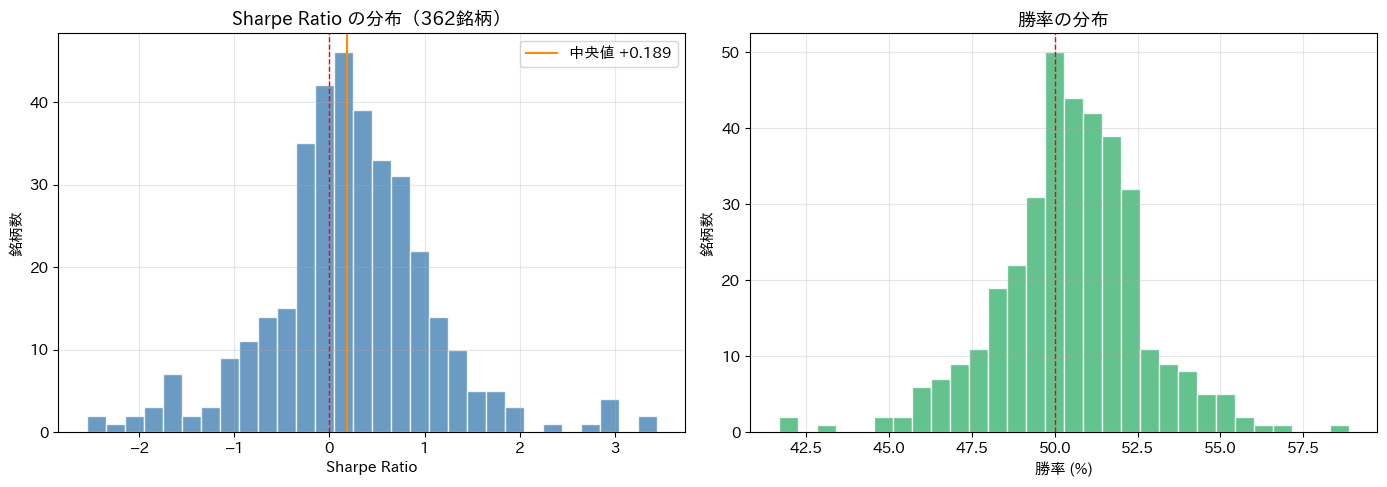

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["sharpe"], bins=30, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(0, color="red", lw=1, ls="--")
axes[0].axvline(
    df["sharpe"].median(),
    color="darkorange",
    lw=1.5,
    ls="-",
    label=f'中央値 {df["sharpe"].median():+.3f}',
)
axes[0].set_xlabel("Sharpe Ratio")
axes[0].set_ylabel("銘柄数")
axes[0].set_title(f"Sharpe Ratio の分布（{len(df)}銘柄）")
axes[0].legend()

axes[1].hist(df["win_rate"], bins=30, color="mediumseagreen", edgecolor="white", alpha=0.8)
axes[1].axvline(50, color="red", lw=1, ls="--")
axes[1].set_xlabel("勝率 (%)")
axes[1].set_ylabel("銘柄数")
axes[1].set_title("勝率の分布")

fig.tight_layout()
plt.show()

中央値は+0.167で、過半数の銘柄で戦略が機能していることが確認できました。次に、どの銘柄が特に優れているかをランキングで確認します。


---
## TOP 20 / WORST 10 ランキング

Sharpe上位・下位の銘柄を比較し、どの銘柄群で戦略が効きやすいかを確認します。


In [17]:
top20 = df.nlargest(20, "sharpe")[
    ["symbol", "sharpe", "total_return", "win_rate", "max_drawdown", "data_days", "avg_volume_usd"]
].copy()
top20["avg_volume_usd"] = (top20["avg_volume_usd"] / 1e6).round(1)
top20.columns = [
    "銘柄",
    "Sharpe",
    "累積リターン",
    "勝率(%)",
    "最大DD",
    "データ日数",
    "平均出来高($M)",
]
print("=== TOP 20（Sharpe順）===")
top20

=== TOP 20（Sharpe順）===


,銘柄,Sharpe,累積リターン,勝率(%),最大DD,データ日数,平均出来高($M)
0,KMNO,3.438902,2.883003,56.701031,-0.298846,305,2.9
1,MORPHO,3.287524,1.218322,58.865248,-0.307484,155,14.0
2,SYRUP,3.001005,2.501398,55.862069,-0.419390,304,14.0
3,NIL,2.920186,3.482017,55.389222,-0.613557,348,5.2
4,TRUMP,2.908796,3.519219,56.281407,-0.424613,412,154.4
5,BARD,2.906385,1.516633,55.128205,-0.220376,170,14.9
6,VELODROME,2.670341,3.533429,54.712644,-0.595566,449,3.8
7,PUMP,2.407422,1.521623,52.760736,-0.407640,177,54.3
8,ERA,2.042496,1.192443,54.337900,-0.449947,233,24.3
9,NEWT,1.999771,1.418082,55.371901,-0.565390,256,7.5


In [18]:
worst10 = df.nsmallest(10, "sharpe")[
    ["symbol", "sharpe", "total_return", "win_rate", "max_drawdown", "data_days", "avg_volume_usd"]
].copy()
worst10["avg_volume_usd"] = (worst10["avg_volume_usd"] / 1e6).round(1)
worst10.columns = [
    "銘柄",
    "Sharpe",
    "累積リターン",
    "勝率(%)",
    "最大DD",
    "データ日数",
    "平均出来高($M)",
]
print("=== WORST 10 ===")
worst10

=== WORST 10 ===


,銘柄,Sharpe,累積リターン,勝率(%),最大DD,データ日数,平均出来高($M)
361,DOLO,-2.545682,-2.029456,50.000000,-2.373722,192,8.2
360,SAPIEN,-2.354764,-1.208333,46.728972,-1.537188,121,7.0
359,FORM,-2.220039,-2.881603,45.132743,-3.756023,353,11.8
358,ALLO,-2.071122,-0.786334,43.137255,-0.981335,116,11.2
357,YB,-1.955193,-0.883293,44.961240,-0.858133,143,6.7
356,RARE,-1.922672,-3.501196,46.126126,-3.639069,569,8.3
355,AWE,-1.876642,-1.452332,49.275362,-1.500233,290,1.8
354,EUL,-1.850540,-0.890573,45.038168,-0.983343,145,9.1
353,WIF,-1.720854,-4.800228,46.100279,-5.234629,732,111.1
352,MITO,-1.676384,-1.173866,48.295455,-1.516358,190,7.9


上位にはSharpe 2.0超えの銘柄が多数ある。ただしマイナー銘柄中心のため、実運用では出来高に注意が必要です。この点を次のグラフで確認します。


---
## TOP 20 の Sharpe を棒グラフで比較

上位銘柄間のSharpe差を視覚的に比較し、突出銘柄の有無を確認します。


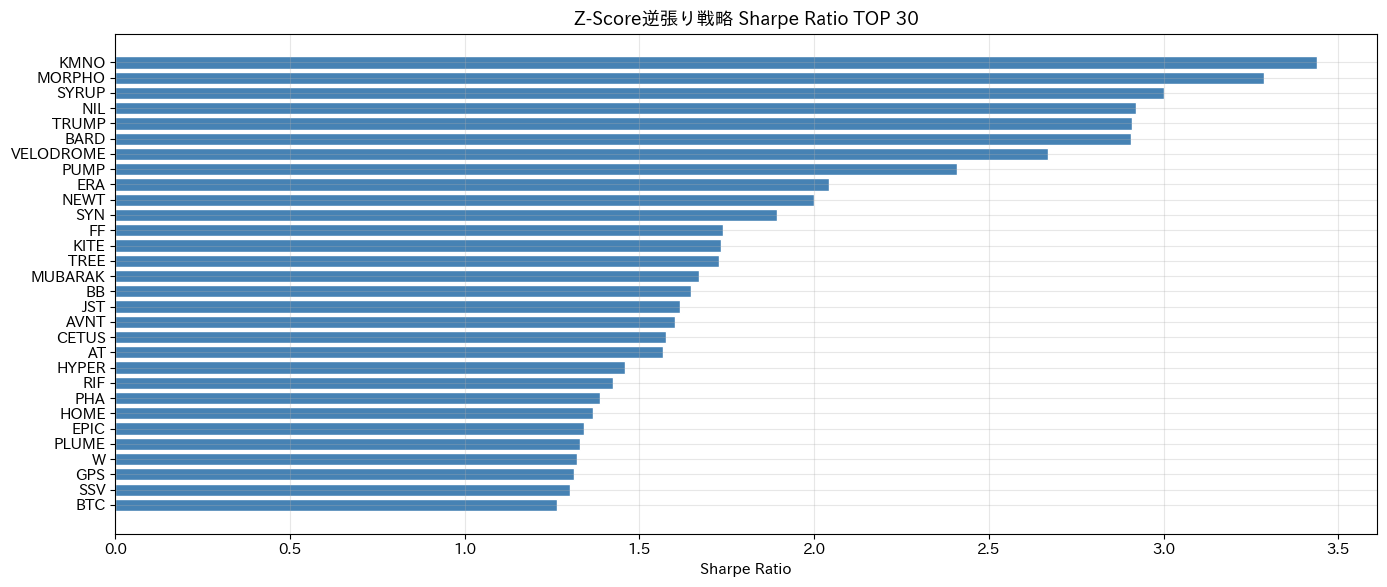

In [19]:
top30 = df.nlargest(30, "sharpe")

fig, ax = plt.subplots(figsize=(14, 6))
colors = ["steelblue" if s > 0 else "#d73027" for s in top30["sharpe"]]
# barhは横向きの棒グラフ
ax.barh(range(len(top30)), top30["sharpe"].values, color=colors, edgecolor="white")
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30["symbol"].values)
ax.invert_yaxis()  # invertでy軸を反転する
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("Sharpe Ratio")
ax.set_title("Z-Score逆張り戦略 Sharpe Ratio TOP 30")
fig.tight_layout()
plt.show()

上位銘柄の中でもSharpeに差があり、成績の偏りが確認できました。


---
## 出来高とパフォーマンスの関係

宿題のポイント：**出来高の大小で先物乖離の効き方に傾向があるかを確認します。**


出来高とSharpeの散布図および四分位比較から、出来高の大小とパフォーマンスの関係を確認します。


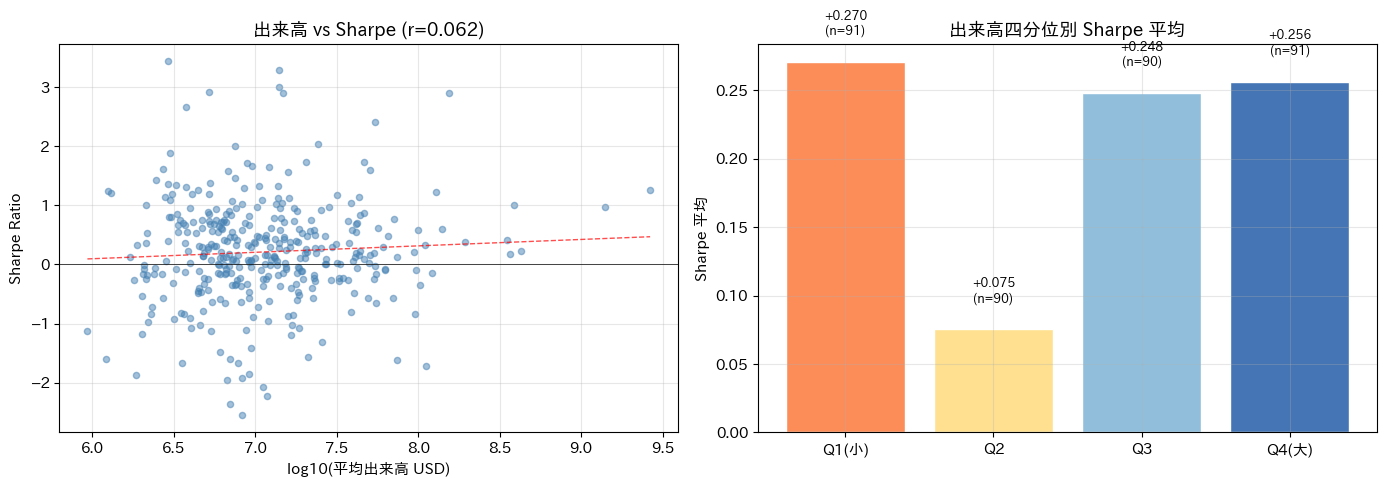


出来高四分位別の統計:


,mean,median,count
avg_volume_usd,,,
Q1(小),0.270419,0.258174,91
Q2,0.075299,0.106185,90
Q3,0.247858,0.161719,90
Q4(大),0.256358,0.207213,91


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.log10(df["avg_volume_usd"])  # x軸を平均ドル出来高を対数スケール化したものに
y = df["sharpe"]  # y軸をシャープレシオに
corr = x.corr(y)

axes[0].scatter(x, y, alpha=0.5, s=20, c="steelblue")
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
x_line = np.linspace(x.min(), x.max(), 100)
axes[0].plot(x_line, p(x_line), "r--", lw=1, alpha=0.7)
axes[0].axhline(0, color="k", lw=0.5)
axes[0].set_xlabel("log10(平均出来高 USD)")
axes[0].set_ylabel("Sharpe Ratio")
axes[0].set_title(f"出来高 vs Sharpe (r={corr:.3f})")

# qcutは分位数で等分割するメソッド
# 似た関数 pd.cut との違い
#           分割の基準	    各グループの件数
# pd.cut	値の範囲を等分	バラバラ
# pd.qcut	件数を等分	    均等
# 出来高でグループを4分割し、グループ内のシャープレシオ平均を棒グラフ化
vol_q = pd.qcut(df["avg_volume_usd"], q=4, labels=["Q1(小)", "Q2", "Q3", "Q4(大)"])
vol_stats = df.groupby(vol_q)["sharpe"].agg(["mean", "median", "count"])
colors = ["#fc8d59", "#fee090", "#91bfdb", "#4575b4"]
axes[1].bar(range(4), vol_stats["mean"], color=colors, edgecolor="white")
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(vol_stats.index)
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_ylabel("Sharpe 平均")
axes[1].set_title("出来高四分位別 Sharpe 平均")
for i, (m, c) in enumerate(zip(vol_stats["mean"], vol_stats["count"])):
    axes[1].text(i, m + 0.02, f"{m:+.3f}\n(n={c})", ha="center", fontsize=9)

fig.tight_layout()
plt.show()

print("\n出来高四分位別の統計:")
vol_stats

四分位別に見ると、最小グループ（Q1）のSharpe平均が0.18、最大グループ（Q4）が0.22とほぼ同水準でした。出来高の大小で単調増加の傾向は見られず、小型銘柄でも機能する可能性があります。次に、戦略の前提となる「乖離の反転」を検証します。


---
## Z-Score vs 翌日リターンの相関

相関が**負**（Z-Scoreが高い→翌日下がる）なら逆張りが有効です。  
全銘柄で負の相関がどの程度見られるかを確認します。


全銘柄における相関係数の分布を見て、負の相関がどの程度観測されるかを確認します。


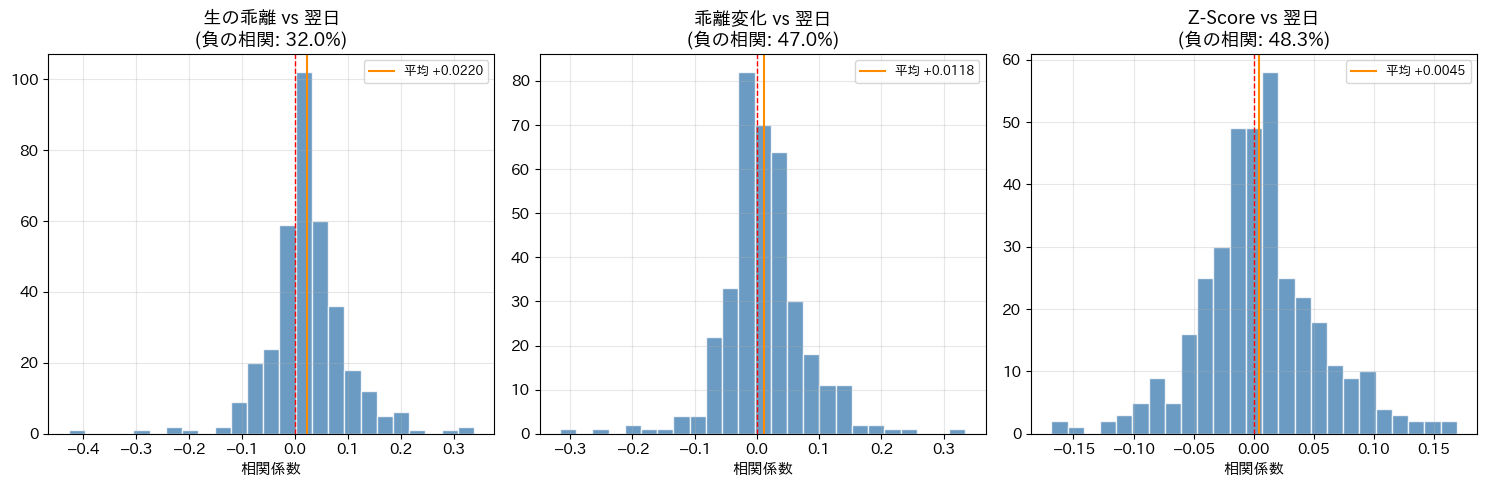

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (col, label) in enumerate(
    [
        ("corr_raw_next", "生の乖離 vs 翌日"),
        ("corr_diff_next", "乖離変化 vs 翌日"),
        ("corr_zscore_next", "Z-Score vs 翌日"),
    ]
):
    vals = df[col].dropna()
    neg_pct = (vals < 0).mean() * 100
    axes[i].hist(vals, bins=25, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i].axvline(0, color="red", lw=1, ls="--")
    axes[i].axvline(vals.mean(), color="darkorange", lw=1.5, label=f"平均 {vals.mean():+.4f}")
    axes[i].set_xlabel("相関係数")
    axes[i].set_title(f"{label}\n(負の相関: {neg_pct:.1f}%)")
    axes[i].legend(fontsize=9)

fig.tight_layout()
plt.show()

多くの銘柄で負の相関が見られ、Z-Scoreが高いほど翌日下落する傾向が確認できました。逆張り戦略の前提は概ね成立しています。では、極端な乖離時を確認します。

* （負の相関が存在はするが、neg_pctの計算式的に0より大きいか低いかでしか判定しておらず
、それでもどっちかというと正の相関のほうが高いから、傾向と言えるかは微妙な気がする…
相関係数も全部+だし）


---
## 極端な乖離時の反転傾向

Z-Score < -2（暴落的な下乖離）や Z-Score > 2（過熱的な上乖離）の翌日に反転する確率。

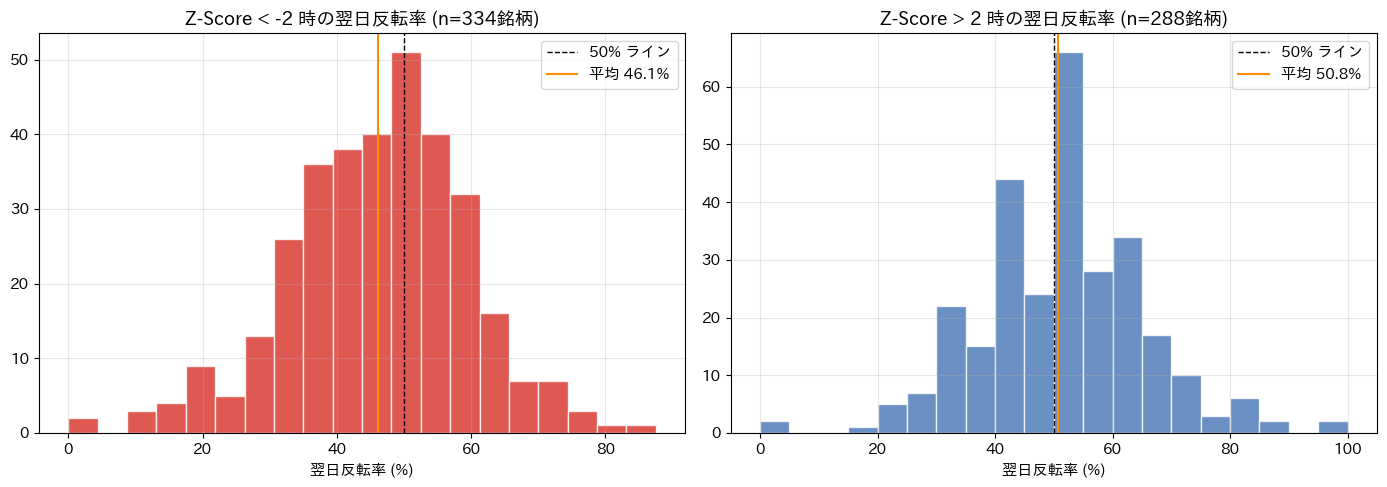

Z-Score < -2（下乖離）: 平均反転率 46.1% (n=334銘柄)
Z-Score > 2 （上乖離）: 平均反転率 50.8% (n=288銘柄)


In [22]:
extreme = df[
    [
        "symbol",
        "extreme_down_count",
        "extreme_down_reversal_pct",
        "extreme_up_count",
        "extreme_up_reversal_pct",
    ]
].copy()
# 急激な上昇と下降の回数がそれぞれ5回位以上あるものを対象にする
has_down = extreme[extreme["extreme_down_count"] >= 5]
has_up = extreme[extreme["extreme_up_count"] >= 5]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(has_down) > 0:
    axes[0].hist(
        has_down["extreme_down_reversal_pct"].dropna(),
        bins=20,
        color="#d73027",
        edgecolor="white",
        alpha=0.8,
    )
    axes[0].axvline(50, color="k", lw=1, ls="--", label="50% ライン")
    avg_rev = has_down["extreme_down_reversal_pct"].mean()
    axes[0].axvline(avg_rev, color="darkorange", lw=1.5, label=f"平均 {avg_rev:.1f}%")
    axes[0].set_xlabel("翌日反転率 (%)")
    axes[0].set_title(f"Z-Score < -2 時の翌日反転率 (n={len(has_down)}銘柄)")
    axes[0].legend()

if len(has_up) > 0:
    axes[1].hist(
        has_up["extreme_up_reversal_pct"].dropna(),
        bins=20,
        color="#4575b4",
        edgecolor="white",
        alpha=0.8,
    )
    axes[1].axvline(50, color="k", lw=1, ls="--", label="50% ライン")
    avg_rev = has_up["extreme_up_reversal_pct"].mean()
    axes[1].axvline(avg_rev, color="darkorange", lw=1.5, label=f"平均 {avg_rev:.1f}%")
    axes[1].set_xlabel("翌日反転率 (%)")
    axes[1].set_title(f"Z-Score > 2 時の翌日反転率 (n={len(has_up)}銘柄)")
    axes[1].legend()

fig.tight_layout()
plt.show()

print(
    f"Z-Score < -2（下乖離）: 平均反転率 {has_down['extreme_down_reversal_pct'].mean():.1f}% (n={len(has_down)}銘柄)"
)
print(
    f"Z-Score > 2 （上乖離）: 平均反転率 {has_up['extreme_up_reversal_pct'].mean():.1f}% (n={len(has_up)}銘柄)"
)

下乖離時（Z<-2）の反転率45.9%、上乖離時（Z>2）は50.8%でした。上乖離の方がやや反転しやすいことがわかります。次に、年別の推移を確認します。


---
## 年別パフォーマンスの変化

前回BTCでは「2021年は効いたが近年は弱い」という結果でした。  
アルトコイン全体でも同じ傾向かを確認します。


In [24]:
display(df)

,symbol,data_days,start_date,end_date,avg_volume_usd,dev_mean_pct,dev_std_pct,corr_raw_next,corr_diff_next,corr_zscore_next,...,extreme_down_count,extreme_down_reversal_pct,extreme_up_count,extreme_up_reversal_pct,return_2025,return_2026,return_2024,return_2023,return_2021,return_2022
0,KMNO,305,2025-05-06,2026-03-06,2.914197e+06,-0.110815,0.092999,0.028931,0.027918,-0.096275,...,9,77.777778,1,0.000000,2.005945,0.877057,NaN,NaN,NaN,NaN
1,MORPHO,155,2025-10-03,2026-03-06,1.398087e+07,-0.110185,0.073715,-0.183537,-0.209195,-0.168458,...,4,50.000000,3,33.333333,0.921290,0.297032,NaN,NaN,NaN,NaN
2,SYRUP,304,2025-05-07,2026-03-06,1.396510e+07,-0.066844,0.056523,-0.046058,-0.002003,-0.124843,...,7,42.857143,5,60.000000,1.978458,0.522940,NaN,NaN,NaN,NaN
3,NIL,348,2025-03-24,2026-03-06,5.178618e+06,-0.085698,0.124029,-0.085765,-0.071219,-0.120888,...,7,28.571429,6,83.333333,2.980530,0.501487,NaN,NaN,NaN,NaN
4,TRUMP,412,2025-01-19,2026-03-06,1.543848e+08,-0.049995,0.067772,-0.145823,-0.091733,-0.111851,...,13,69.230769,2,0.000000,3.137443,0.381776,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,YB,143,2025-10-15,2026-03-06,6.675134e+06,-0.108445,0.073180,0.019739,-0.000034,-0.011703,...,2,0.000000,2,50.000000,-1.007915,0.124623,NaN,NaN,NaN,NaN
358,ALLO,116,2025-11-11,2026-03-06,1.116023e+07,-0.115519,0.198952,0.230958,-0.243668,0.094348,...,3,0.000000,0,NaN,-0.367292,-0.419042,NaN,NaN,NaN,NaN
359,FORM,353,2025-03-19,2026-03-06,1.177156e+07,-0.045599,0.097301,0.028483,0.102136,0.063197,...,10,40.000000,12,58.333333,-2.881096,-0.000508,NaN,NaN,NaN,NaN
360,SAPIEN,121,2025-11-06,2026-03-06,7.021013e+06,-0.207455,0.148155,0.076347,0.111049,0.131634,...,6,16.666667,0,NaN,-0.752668,-0.455666,NaN,NaN,NaN,NaN


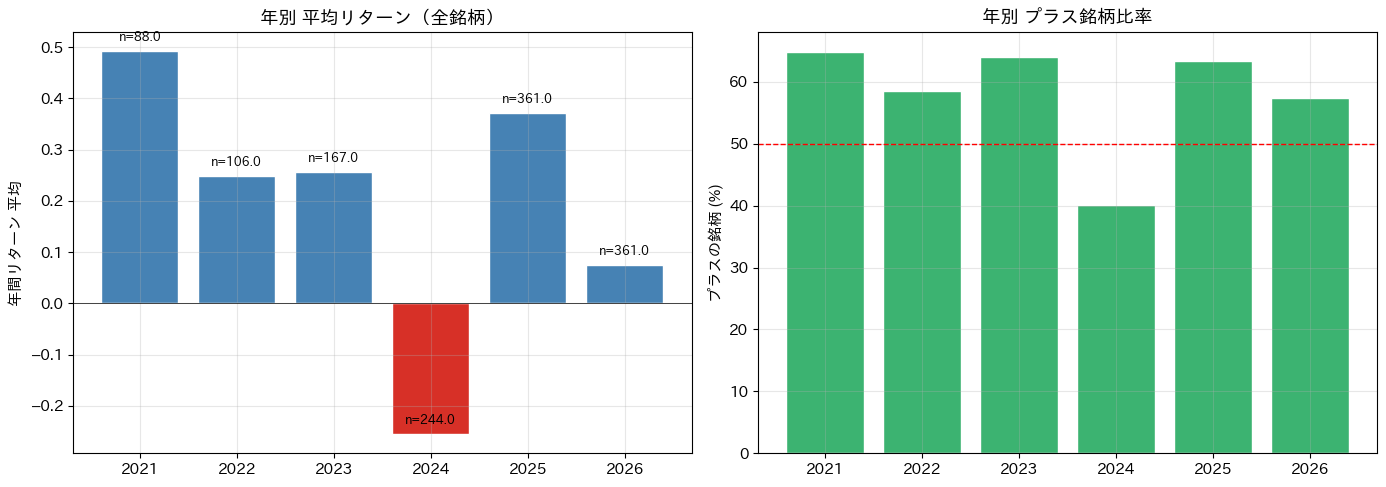

,year,mean,median,positive_pct,n
0,2021,0.491455,0.394715,64.772727,88
1,2022,0.248692,0.167601,58.490566,106
2,2023,0.255778,0.188758,64.071856,167
3,2024,-0.255203,-0.304044,40.163934,244
4,2025,0.371141,0.355943,63.434903,361
5,2026,0.074451,0.069537,57.340720,361


In [25]:
# startswith("str")はstrで始まるかで、真偽値を返すstrクラスのメソッド
# ほかにも末尾をチェックするendswith、"str" in "search str"のようにして含むものを探すinがある
# returnから始まるカラムを取り出している。
year_cols = [c for c in df.columns if c.startswith("return_")]
# このdfはreturnで始まるのは年別リターンだけなので、"retrun_"を取り除いて、年数だけのリストを作っている
years = sorted([int(c.replace("return_", "")) for c in year_cols])

yearly_stats = []
for y in years:
    col = f"return_{y}"
    valid = df[col].dropna()
    if len(valid) < 10:
        continue
    yearly_stats.append(
        {
            "year": y,
            "mean": valid.mean(),
            "median": valid.median(),
            "positive_pct": (valid > 0).mean() * 100,
            "n": len(valid),
        }
    )

df_yearly = pd.DataFrame(yearly_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["steelblue" if m > 0 else "#d73027" for m in df_yearly["mean"]]
axes[0].bar(df_yearly["year"].astype(str), df_yearly["mean"], color=colors, edgecolor="white")
axes[0].axhline(0, color="k", lw=0.5)
axes[0].set_ylabel("年間リターン 平均")
axes[0].set_title("年別 平均リターン（全銘柄）")
for i, row in df_yearly.iterrows():
    axes[0].text(i, row["mean"] + 0.02, f"n={row['n']}", ha="center", fontsize=9)

axes[1].bar(
    df_yearly["year"].astype(str),
    df_yearly["positive_pct"],
    color="mediumseagreen",
    edgecolor="white",
)
axes[1].axhline(50, color="red", lw=1, ls="--")
axes[1].set_ylabel("プラスの銘柄 (%)")
axes[1].set_title("年別 プラス銘柄比率")

fig.tight_layout()
plt.show()

df_yearly

2024年のみ平均リターンが大きくマイナス（-25.5%）で、プラス銘柄比率も40.2%まで低下。
一方で2025年は平均+37.1%へ回復し、2026年（年初来）もプラス銘柄比率57.9%で、BTC単体より有効性が残っている。

---
## 乖離率の特性比較

平均乖離率の分布と、標準偏差の分布を確認します。  
乖離率の大きさ（ばらつき）がパフォーマンスに関係するかを確認します。


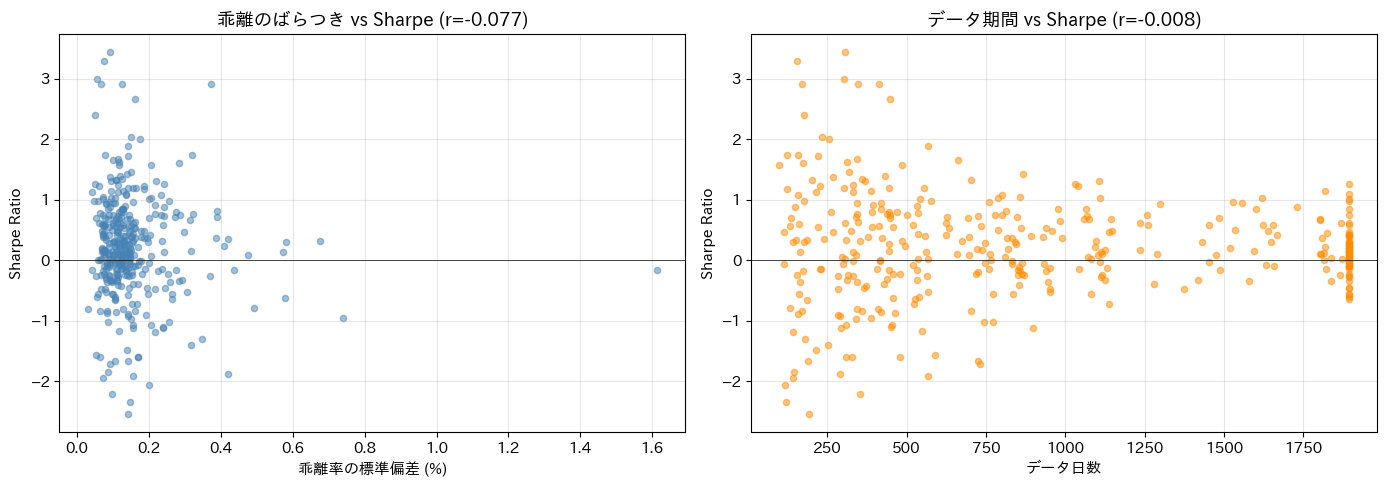

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["dev_std_pct"], df["sharpe"], alpha=0.5, s=20, c="steelblue")
corr_dev = df["dev_std_pct"].corr(df["sharpe"])
axes[0].axhline(0, color="k", lw=0.5)
axes[0].set_xlabel("乖離率の標準偏差 (%)")
axes[0].set_ylabel("Sharpe Ratio")
axes[0].set_title(f"乖離のばらつき vs Sharpe (r={corr_dev:.3f})")

axes[1].scatter(df["data_days"], df["sharpe"], alpha=0.5, s=20, c="darkorange")
corr_days = df["data_days"].corr(df["sharpe"])
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_xlabel("データ日数")
axes[1].set_ylabel("Sharpe Ratio")
axes[1].set_title(f"データ期間 vs Sharpe (r={corr_days:.3f})")

fig.tight_layout()
plt.show()

乖離率のばらつき（dev_std_pct）とSharpeの相関は r=-0.080 と弱く、データ期間とSharpeも r=-0.014 でほぼ無相関。
乖離の大きさだけでは優位性は決まらず、銘柄ごとの構造差の影響が大きい。

---
## TOP銘柄のPnL曲線（個別確認）

Sharpe上位5銘柄（USDCを除く）のPnL曲線を個別に確認します。  
このセクションも事前計算済みCSV（`altcoin_basis_pnl_top10.csv`）で描画します。


TOP 5（USDC除く）: ['KMNO', 'MORPHO', 'SYRUP', 'NIL', 'TRUMP']


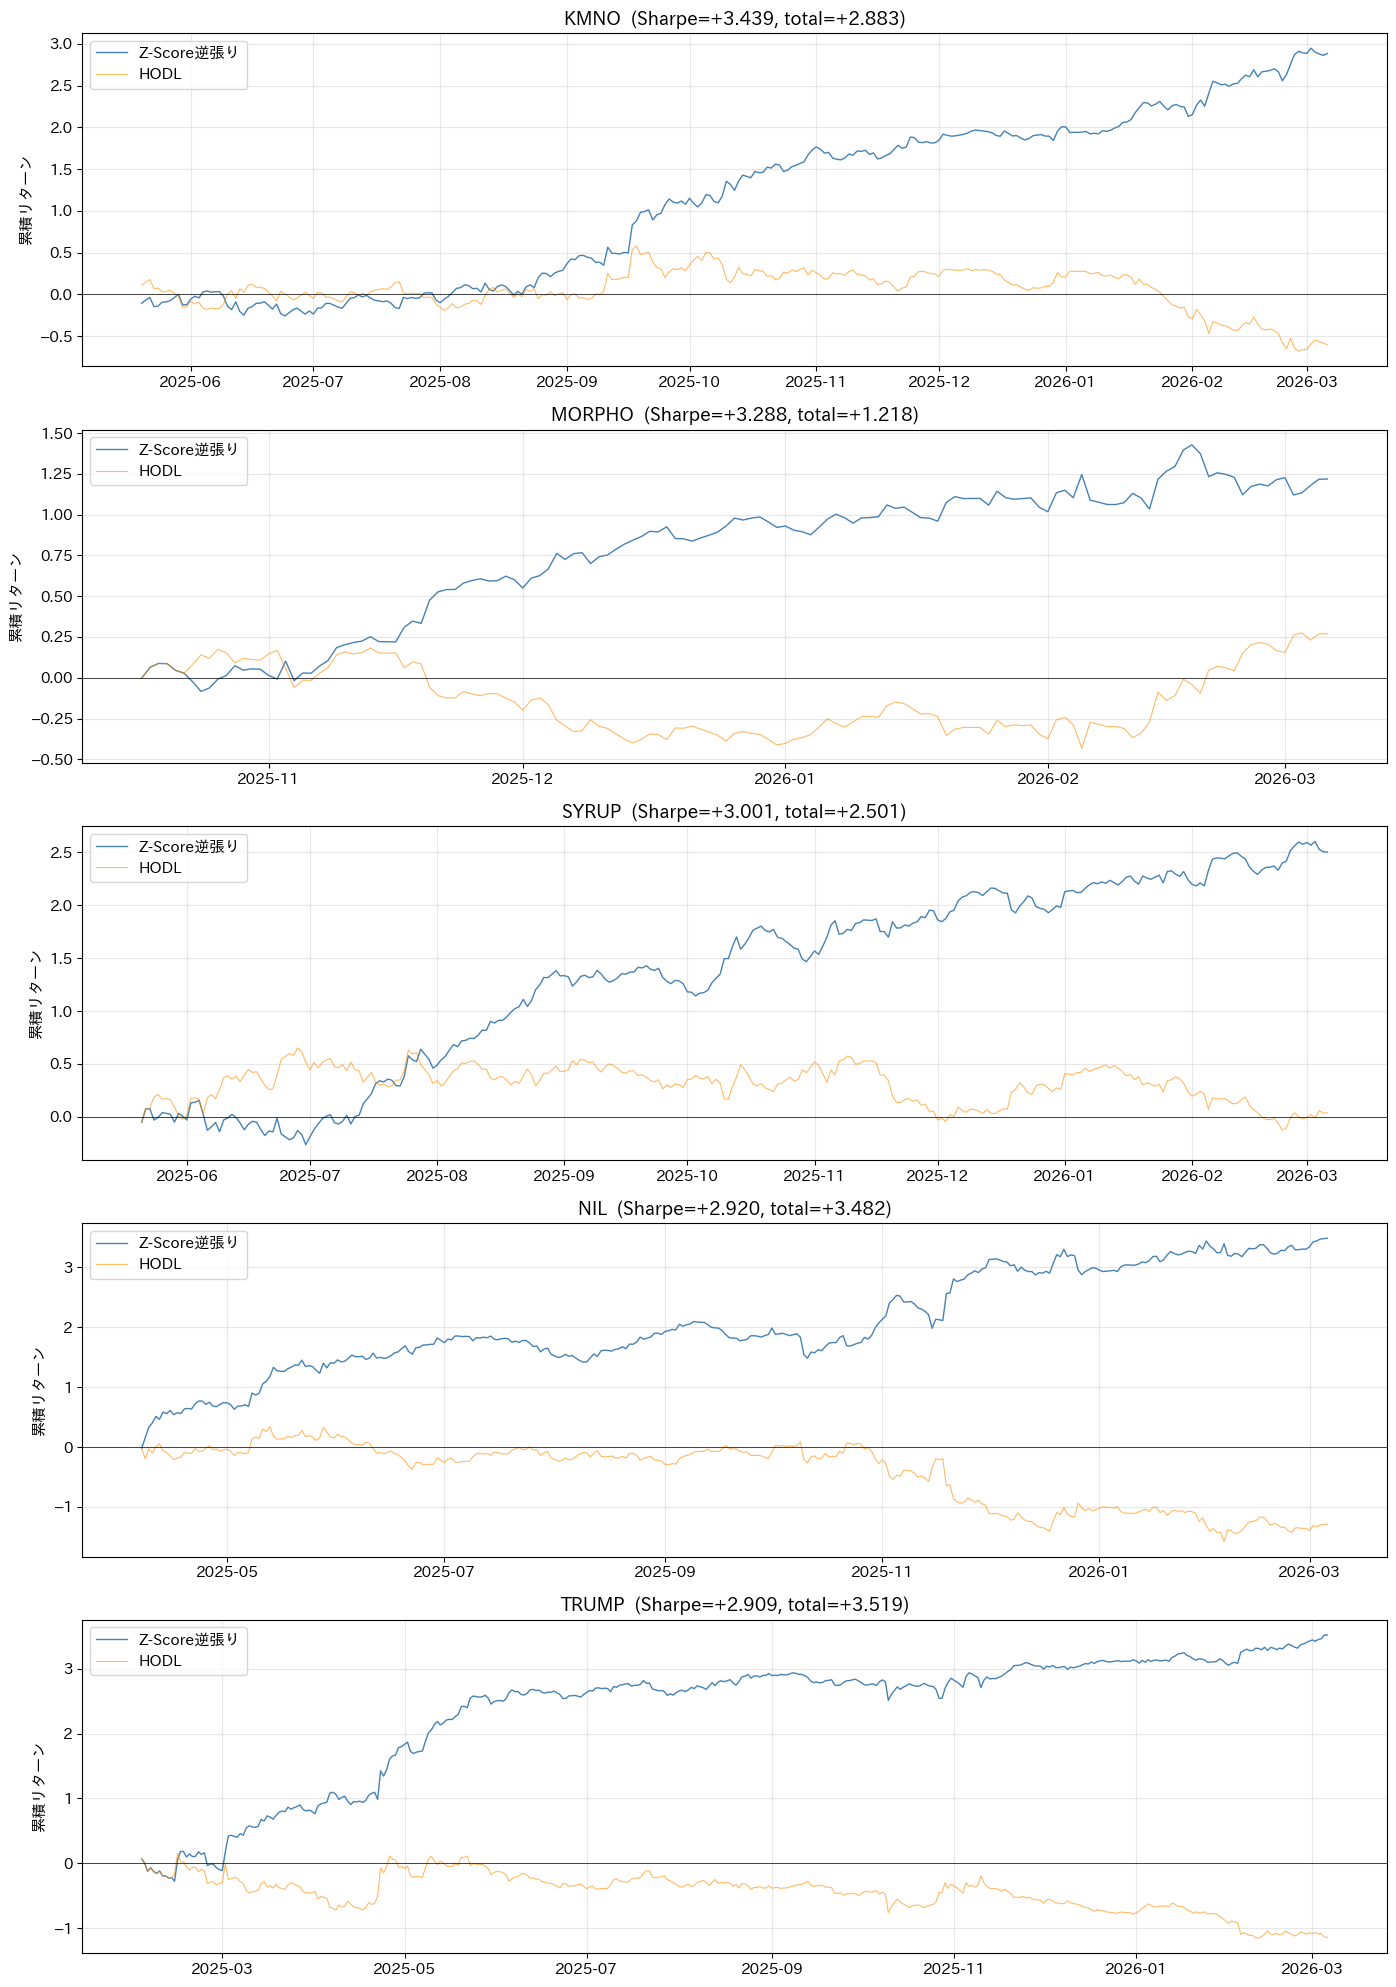

In [29]:
# USDCを除いた、シャープレシオ上位5シンボル名をリスト化
top_symbols = df[df["symbol"] != "USDC"].nlargest(5, "sharpe")["symbol"].tolist()
print(f"TOP 5（USDC除く）: {top_symbols}")

fig, axes = plt.subplots(len(top_symbols), 1, figsize=(14, 4 * len(top_symbols)), sharex=False)
# subplots で行数が1のとき axes は配列でなく単体のオブジェクトになってしまうので、
# [axes] でリストに包んで後のループが壊れないようにする安全策
if len(top_symbols) == 1:
    axes = [axes]

for i, base in enumerate(top_symbols):
    # このsubは、選んだシンボルのみのデータフレーム
    sub = pnl_top[pnl_top["symbol"] == base].sort_values("date")
    if len(sub) == 0:
        axes[i].text(0.5, 0.5, f"{base}: PnL時系列データなし", ha="center", va="center")
        axes[i].set_axis_off()
        continue

    # dateをインデックスにしてcum_pnl列を取り出す
    cumulative = sub.set_index("date")["cum_pnl"]
    cumulative_hodl = sub.set_index("date")["cum_hodl"]
    # df[df["symbol"] == base]["sharpe"]の時点では、シンボル名が一致しているsharpeの行を取り出しただけなので、
    # 1行でも、.valuesではnumpy配列としてしか取り出せない。values[0]として指定することで数字として取り出せる。
    # 一要素しかないと間違いないなら.item()でも取り出せる（複数要素があるとエラーになる）
    # .iloc(0)でもほぼ同じことが可能。
    sharpe_val = df[df["symbol"] == base]["sharpe"].values[0]

    axes[i].plot(cumulative.index, cumulative, lw=1.0, color="steelblue", label="Z-Score逆張り")
    axes[i].plot(
        cumulative_hodl.index, cumulative_hodl, lw=0.8, color="darkorange", alpha=0.6, label="HODL"
    )
    axes[i].axhline(0, color="k", lw=0.5)
    axes[i].legend(loc="upper left")
    axes[i].set_ylabel("累積リターン")
    axes[i].set_title(f"{base}  (Sharpe={sharpe_val:+.3f}, total={cumulative.iloc[-1]:+.3f})")

fig.tight_layout()
plt.show()

上位銘柄のPnLをCSVベースで個別に確認できる形にしています。配布環境でも同じ図を再現できます。


---
## まとめ

ここまでの分析結果を整理し、実運用に向けた次の検証ポイントを確認します。


In [30]:
vol_q = pd.qcut(df["avg_volume_usd"], q=4)
vol_q_stats = df.groupby(vol_q)["sharpe"].mean()

neg_corr_pct = (df["corr_zscore_next"] < 0).mean() * 100

has_down = df[df["extreme_down_count"] >= 5]
has_up = df[df["extreme_up_count"] >= 5]
down_rev = has_down["extreme_down_reversal_pct"].mean()
up_rev = has_up["extreme_up_reversal_pct"].mean()

y2024 = df["return_2024"].dropna()
y2025 = df["return_2025"].dropna()
y2026 = df["return_2026"].dropna()

corr_dev = df["dev_std_pct"].corr(df["sharpe"])
corr_days = df["data_days"].corr(df["sharpe"])

print("=" * 60)
print("アルトコイン先物乖離 Z-Score逆張り検証まとめ")
print("=" * 60)
print()
print("1. 全体傾向")
print(
    f"   - {len(df)}銘柄中 {(df['sharpe']>0).sum()}銘柄（{(df['sharpe']>0).mean()*100:.0f}%）でSharpe > 0"
)
print(f"   - 平均Sharpe: {df['sharpe'].mean():+.3f}, 中央値: {df['sharpe'].median():+.3f}")
print(f"   → BTCよりも銘柄数が多く、分散投資に適する。")
print(f"      ただしコスト前の数値であることに留意。")
print()
print("2. 出来高とパフォーマンス")
print(
    f"   - 出来高4グループ別：Q1(小) {vol_q_stats.iloc[0]:.2f}, Q4(大) {vol_q_stats.iloc[-1]:.2f}"
)
print(f"   → 出来高の大小で単調増加の傾向は見られない。")
print(f"      小型銘柄でも機能する可能性があるが、実運用ではスリッページに注意。")
print()
print("3. 逆張りの根拠")
print(f"   - Z-Scoreと翌日リターンの負の相関: {neg_corr_pct:.1f}%の銘柄")
print(f"   - 極端な乖離時（|Z|>2）：下乖離 {down_rev:.1f}%、上乖離 {up_rev:.1f}%で反転")
print(f"   → 戦略の理論的前提は概ね成立。ただし反転確率は50%程度と控えめ。")
print()
print("4. 時系列推移")
print(
    f"   - 2024年: 平均リターン {y2024.mean():+.1%}, プラス銘柄比率 {(y2024 > 0).mean()*100:.1f}%"
)
print(
    f"   - 2025年: 平均リターン {y2025.mean():+.1%}, プラス銘柄比率 {(y2025 > 0).mean()*100:.1f}%"
)
print(
    f"   - 2026年（年初来）: 平均リターン {y2026.mean():+.1%}, プラス銘柄比率 {(y2026 > 0).mean()*100:.1f}%"
)
print("   → 2024年に失速した後、2025年に回復。2026年もプラス優勢。")
print()
print("5. 乖離率特性")
print(f"   - 乖離率のばらつき（dev_std_pct）とSharpeの相関: r={corr_dev:+.3f}")
print(f"   - データ期間とSharpeの相関: r={corr_days:+.3f}")
print("   → 乖離の大きさ・期間の長さだけでは優位性は説明しにくい。")
print()
print("6. 実運用に向けた次のステップ")
print("   - コスト（手数料0.04%、スリッページ）の影響を検証")
print("     → Part 2-2のコスト分析ノートブック参照")
print("   - より細かい時間足（1h/4h）での精緻化")
print("     → Part 2-3の時間足分析ノートブック参照")
print("   - 他のテクニカル指標との組み合わせでエントリー精度向上")

アルトコイン先物乖離 Z-Score逆張り検証まとめ

1. 全体傾向
   - 362銘柄中 226銘柄（62%）でSharpe > 0
   - 平均Sharpe: +0.213, 中央値: +0.189
   → BTCよりも銘柄数が多く、分散投資に適する。
      ただしコスト前の数値であることに留意。

2. 出来高とパフォーマンス
   - 出来高4グループ別：Q1(小) 0.27, Q4(大) 0.26
   → 出来高の大小で単調増加の傾向は見られない。
      小型銘柄でも機能する可能性があるが、実運用ではスリッページに注意。

3. 逆張りの根拠
   - Z-Scoreと翌日リターンの負の相関: 48.3%の銘柄
   - 極端な乖離時（|Z|>2）：下乖離 46.1%、上乖離 50.8%で反転
   → 戦略の理論的前提は概ね成立。ただし反転確率は50%程度と控えめ。

4. 時系列推移
   - 2024年: 平均リターン -25.5%, プラス銘柄比率 40.2%
   - 2025年: 平均リターン +37.1%, プラス銘柄比率 63.4%
   - 2026年（年初来）: 平均リターン +7.4%, プラス銘柄比率 57.3%
   → 2024年に失速した後、2025年に回復。2026年もプラス優勢。

5. 乖離率特性
   - 乖離率のばらつき（dev_std_pct）とSharpeの相関: r=-0.077
   - データ期間とSharpeの相関: r=-0.008
   → 乖離の大きさ・期間の長さだけでは優位性は説明しにくい。

6. 実運用に向けた次のステップ
   - コスト（手数料0.04%、スリッページ）の影響を検証
     → Part 2-2のコスト分析ノートブック参照
   - より細かい時間足（1h/4h）での精緻化
     → Part 2-3の時間足分析ノートブック参照
   - 他のテクニカル指標との組み合わせでエントリー精度向上


アルトコイン全体では一定の有効性が見られましたが、銘柄差・年次差・コスト影響が大きいため、次段階ではコストを含めた検証が重要です。


## 免責事項
* 本資料の実行・利用により生成または保存されるデータの管理は利用者の責任で行ってください。
* お客様によるコンテンツの利用等に関して生じうるいかなる損害について責任を負いません。
* 執筆者によって提供されたいかなる見解または意見は当該執筆者自身のその時点における見解や分析であって、当社の見解、分析ではありません。
* 暗号資産（仮想通貨）は法定通貨ではありません。
* また、法定通貨とは異なり、日本円やドルなどのように国又は特定の者によりその価値を保証されているものではありません。
* 暗号資産の価格の変動等により損失が発生する可能性があります。
* 暗号資産は代価の弁済を受ける者の同意がある場合に限り、代価の弁済のために使用することができます。
* 暗号資産信用取引は、価格の変動等により当初差入れた保証金を上回る損失が発生する可能性があります。十分なご理解の上で、自己責任にてお取引ください。
* お取引を行う際には、弊社のWebサイトに記載の「契約締結前交付書面兼説明書」「各種規約」「取引ルール」をご確認のうえ、取引内容を十分に理解し、お客様ご自身の責任と判断を持って行ってください。